In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
import mne

## Datos reales

In [5]:
# Leer el archivo EDF de PhysioNet (Sujeto 2, Run 1: Ojos abiertos con parpadeos) -> https://physionet.org/content/eegmmidb/1.0.0/ <-
data_path = 'S001R01.edf' # Ajusta el path
raw = mne.io.read_raw_edf(data_path, preload=True)
t = np.linspace(0, 61, 9760)
# Seleccionar solo los canales de EEG y extraer la matriz de datos
raw.pick_types(eeg=True)
X = raw.get_data().T  # Matriz de dimensiones: (muestras x 64 canales)

Extracting EDF parameters from S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).


In [6]:
#Graficando unos cuantos canales
def grafica(X,t,titulo,cual):
    fig, axs = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
    axs[0].plot(t, X[:, cual+0], color='black', label='Canal 1')
    axs[0].set_title(titulo)
    axs[0].grid(True)

    axs[1].plot(t, X[:, cual+1], color='black', label='cANAL 2')
    axs[1].grid(True)

    axs[2].plot(t, X[:, cual+2], color='black', label='Canal 3')
    axs[2].grid(True)

    axs[3].plot(t, X[:,cual+3], color='black', label='Canal 4')
    axs[3].grid(True)

    plt.xlabel('Tiempo (s)')
    plt.tight_layout()
    plt.show()
    return

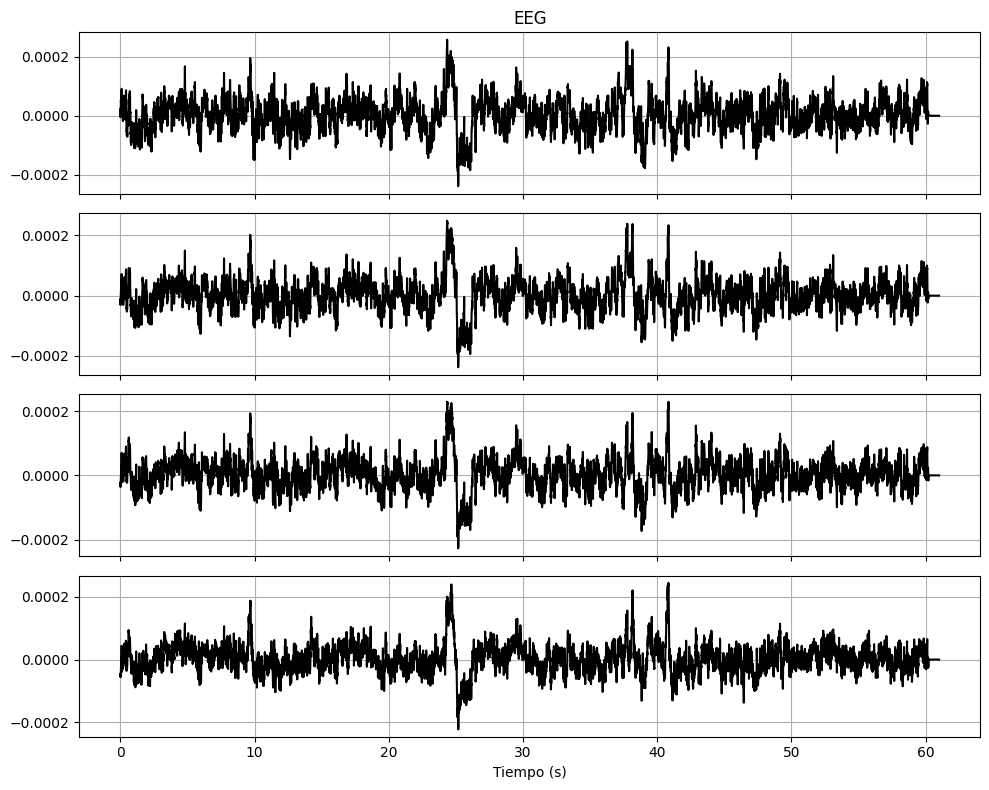

In [7]:
grafica(X,t,"EEG",3)

## Descomposición en CP

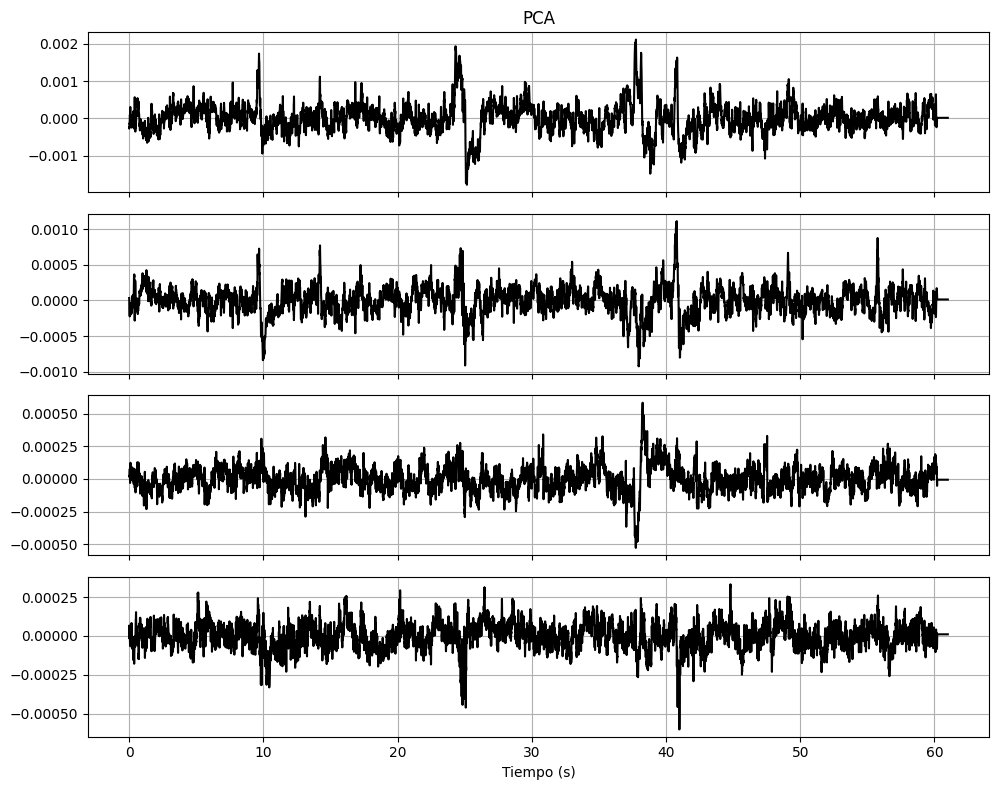

In [8]:
pca = PCA(n_components=0.95)  #Hasta acumular el 95% de variabilidad
X_transformed = pca.fit_transform(X)  # Proyectar a Componentes Principales (PCs)
grafica(X_transformed,t,"PCA",0)

## Filtrado

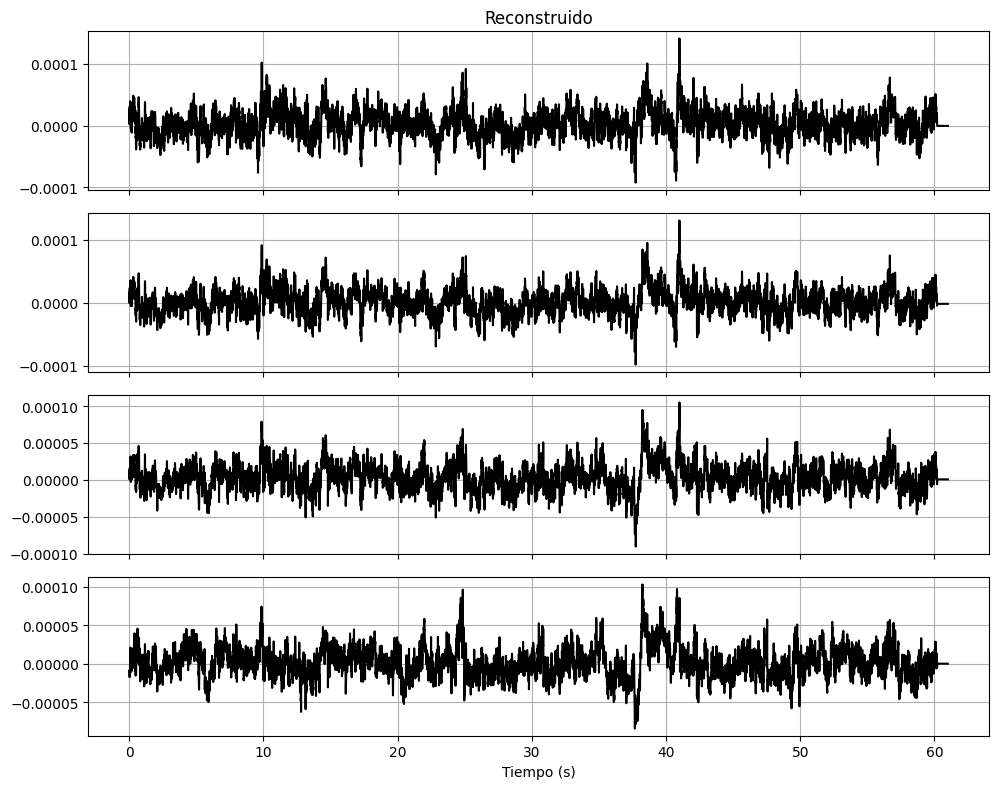

In [9]:
# Filtrado: Identificar y eliminar la componente del artefacto
# La PC1 usualmente captura la mayor varianza (el parpadeo, al ser enorme, estará aquí)
X_transformed_filtered = X_transformed.copy()
X_transformed_filtered[:, 0] = 0  # Ponemos a cero los componentes no deseados (parpadeo, por ejemplo)

# 5. Reconstruir la señal limpia volviendo al espacio original de los canales
X_cleaned = pca.inverse_transform(X_transformed_filtered)

# --- Graficar los Resultados ---
grafica(X_cleaned,t,"Reconstruido",3)